## Level 4 – Weather-Driven Highway Accidents

## Problem Statement

Supervised regression problem. We aim to predict the daily number of road accidents on highways using meteorological data. The objective is to help Grupo Brisa manage emergency vehicle allocation, in which 3 vehicles are needed per accident.

**Why a Supervised Learning Problem?**
- Labeled target values (daily accident counts per location)
- We want to measure prediction accuracy with a specific error metric
- Training on historical weather, relationships to predict future accidents

**Prediction Task:** Given daily weather features (temperature, humidity, rainfall, wind, pressure, etc.) for a location and date, predict the number of accidents that will occur.

**Evaluation Metric (Vehicle Error):**
Vehicle Error = |3 x actual_accidents − predicted_vehicles|

Predicted_vehicles is our model's predicted accident count x 3. This metric penalizes both overestimation (too many vehicles sent) and underestimation (insufficient response). **This is an important security topic, we should always favor overestimation over underestimation.**

**Data Overview:**
- **Accidents Dataset**: Daily accident counts per location (18 districts, from 2025-12-29 to 2026-03-05)
- **Meteorology Dataset**: Hourly weather measurements per location (starting 2025-03-05, multiple features including temperature, humidity, rain, wind, pressure)
- **Objective**: Align hourly weather data to daily granularity and match time periods.

**Approach:**
1. Load and explore datasets
2. Align temporal ranges and aggregate hourly weather to daily
3. Exploratory analysis (EDA) with visualizations (correlations, distributions, outliers)
4. Feature engineering based on graphical evidence
5. Train-validation-test split (70-15-15, chronological order)
6. Train linear regression as baseline
7. Evaluate with Vehicle Error metric
8. Plan for addittions (snow feature, more complex/self-made models)

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
DATA_PATH = "../data/meteorology_dataset.csv"
accidents_path = Path("../data/accidents_dataset.csv")
meteorology_path = Path("../data/meteorology_dataset_with_snow_fall.csv")

In [165]:
# Load datasets
accidents_df = pd.read_csv(accidents_path)
meteorology_df = pd.read_csv(meteorology_path)

print("="*80)
print("ACCIDENTS DATASET")
print("="*80)
print(f"Shape: {accidents_df.shape}")
print(f"\nColumn names and types:")
print(accidents_df.dtypes)
print(f"\nFirst few rows:")
print(accidents_df.head(10))
print(f"\nBasic statistics:")
print(accidents_df.describe())

ACCIDENTS DATASET
Shape: (1206, 3)

Column names and types:
location       str
accidents    int64
time           str
dtype: object

First few rows:
         location  accidents        time
0          Aveiro         36  2025-12-29
1            Beja          7  2025-12-29
2           Braga         22  2025-12-29
3        Bragança          7  2025-12-29
4  Castelo Branco         11  2025-12-29
5         Coimbra         12  2025-12-29
6           Évora         10  2025-12-29
7            Faro         28  2025-12-29
8          Guarda          9  2025-12-29
9          Leiria         13  2025-12-29

Basic statistics:
         accidents
count  1206.000000
mean     23.539801
std      24.303537
min       0.000000
25%       6.000000
50%      15.000000
75%      31.000000
max     144.000000


In [166]:
print("\n" + "="*80)
print("METEOROLOGY DATASET")
print("="*80)
print(f"Shape: {meteorology_df.shape}")
print(f"\nColumn names and types:")
print(meteorology_df.dtypes)
print(f"\nFirst few rows:")
print(meteorology_df.head(10))
print(f"\nBasic statistics (sample of numeric columns):")
print(meteorology_df.describe())


METEOROLOGY DATASET
Shape: (158112, 18)

Column names and types:
location                    str
time                        str
temperature_2m          float64
relative_humidity_2m      int64
dew_point_2m            float64
rain                    float64
cloud_cover               int64
cloud_cover_low           int64
cloud_cover_mid           int64
cloud_cover_highh         int64
wind_speed_10m          float64
wind_direction_10m        int64
wind_gusts_10m          float64
wind_direction_100m       int64
wind_speed_100m         float64
pressure_msl            float64
surface_pressure        float64
snow_fall                 int64
dtype: object

First few rows:
  location                 time  temperature_2m  relative_humidity_2m  \
0   Aveiro  2025-03-05 00:00:00            11.6                    79   
1   Aveiro  2025-03-05 01:00:00            11.2                    90   
2   Aveiro  2025-03-05 02:00:00            11.1                    90   
3   Aveiro  2025-03-05 03:00:00    

In [167]:
# Check temporal ranges and data alignment
print("\n" + "="*80)
print("DATA ALIGNMENT & TEMPORAL RANGES")
print("="*80)

# Accidents data
accidents_df['time'] = pd.to_datetime(accidents_df['time'])
print(f"\nAccidents data date range: {accidents_df['time'].min()} to {accidents_df['time'].max()}")
print(f"Locations in accidents data: {accidents_df['location'].nunique()}")
print(f"Unique locations: {sorted(accidents_df['location'].unique())}")

# Meteorology data
meteorology_df['time'] = pd.to_datetime(meteorology_df['time'])
print(f"\nMeteorology data date range: {meteorology_df['time'].min()} to {meteorology_df['time'].max()}")
print(f"Locations in meteorology data: {meteorology_df['location'].nunique()}")

# Data alignment issue
print(f"\nTemporal Range Issue:")
print(f"  - Meteorology starts: {meteorology_df['time'].min()}")
print(f"  - Accidents starts: {accidents_df['time'].min()}")
print(f"  - Meteorology data BEFORE accidents: {(meteorology_df['time'].min() < accidents_df['time'].min())}")
print(f"  - Days to trim from meteorology: {(accidents_df['time'].min() - meteorology_df['time'].min()).days} days")
print(f"\nAction: We will trim meteorology data to start from {accidents_df['time'].min()}")


DATA ALIGNMENT & TEMPORAL RANGES

Accidents data date range: 2025-12-29 00:00:00 to 2026-03-05 00:00:00
Locations in accidents data: 18
Unique locations: ['Aveiro', 'Beja', 'Braga', 'Bragança', 'Castelo Branco', 'Coimbra', 'Faro', 'Guarda', 'Leiria', 'Lisboa', 'Portalegre', 'Porto', 'Santarém', 'Setúbal', 'Viana do Castelo', 'Vila Real', 'Viseu', 'Évora']

Meteorology data date range: 2025-03-05 00:00:00 to 2026-03-05 23:00:00
Locations in meteorology data: 18

Temporal Range Issue:
  - Meteorology starts: 2025-03-05 00:00:00
  - Accidents starts: 2025-12-29 00:00:00
  - Meteorology data BEFORE accidents: True
  - Days to trim from meteorology: 299 days

Action: We will trim meteorology data to start from 2025-12-29 00:00:00


## Phase 2: Data Preparation & Alignment

### Step 1: Trim and Aggregate Meteorology Data

As the meteorology dataset starts in March 2025, but accident data only begins on 2025-12-29. We need to:
1. Remove all meteorology data before the first accident date
2. Aggregate hourly weather measurements to daily statistics (mean, max, min when appropriate)
3. Align both datasets by location and date for merging

This aggregation is justified by the task: we want to predict daily accidents from daily weather patterns. The loss of information is justified by the proportional gains in predictive power.

In [168]:
# Trim meteorology data to match accidents time interaval
cutoff_date = accidents_df['time'].min()

meteorology_df_trimmed = meteorology_df[meteorology_df['time'] >= cutoff_date].copy()

print("METEOROLOGY DATA TRIMMING")
print("="*80)
print(f"Original meteorology shape: {meteorology_df.shape}")
print(f"Trimmed meteorology shape: {meteorology_df_trimmed.shape}")
print(f"Date range after trim: {meteorology_df_trimmed['time'].min()} to {meteorology_df_trimmed['time'].max()}")
print(f"Records removed: {meteorology_df.shape[0] - meteorology_df_trimmed.shape[0]}")


METEOROLOGY DATA TRIMMING
Original meteorology shape: (158112, 18)
Trimmed meteorology shape: (28944, 18)
Date range after trim: 2025-12-29 00:00:00 to 2026-03-05 23:00:00
Records removed: 129168


In [169]:
# Step 2: Aggregate hourly to daily meteorology data
# Clean column names (strip whitespace) so aggregation keys match
meteorology_df_trimmed.columns = meteorology_df_trimmed.columns.str.strip()

# Extract date (without time) for grouping
meteorology_df_trimmed['date'] = meteorology_df_trimmed['time'].dt.date

# Aggregation strategy:
# - Temperature, humidity, dew point, pressure: daily MEAN (representative of daily conditions)
# - Rain: daily SUM (total precipitation for the day)
# - Cloud cover: daily MEAN
# - Wind: daily MEAN (average wind speed)
# - Snow: daily MAX (whether snowfall occurred during the day)
aggregation_ops = {
    'temperature_2m': 'mean',
    'relative_humidity_2m': 'mean',
    'dew_point_2m': 'mean',
    'rain': 'sum',
    'cloud_cover': 'mean',
    'cloud_cover_low': 'mean',
    'cloud_cover_mid': 'mean',
    'cloud_cover_highh': 'mean',
    'wind_speed_10m': 'mean',
    'wind_direction_10m': 'mean',
    'wind_gusts_10m': 'mean',
    'wind_direction_100m': 'mean',
    'wind_speed_100m': 'mean',
    'pressure_msl': 'mean',
    'surface_pressure': 'mean'
}

if 'snow_fall' in meteorology_df_trimmed.columns:
    aggregation_ops['snow_fall'] = 'max'

meteorology_daily = meteorology_df_trimmed.groupby(['location', 'date']).agg(aggregation_ops).reset_index()

# Convert date back to datetime for consistency
meteorology_daily['date'] = pd.to_datetime(meteorology_daily['date'])

print('METEOROLOGY DAILY AGGREGATION')
print('='*80)
print(f"Daily meteorology shape: {meteorology_daily.shape}")
print(f"Locations: {meteorology_daily['location'].nunique()}")
print(f"Date range: {meteorology_daily['date'].min()} to {meteorology_daily['date'].max()}")
print(f"Days of data: {meteorology_daily['date'].nunique()}")
print(f"Snow column present: {'snow_fall' in meteorology_daily.columns}")
print('\nFirst 5 rows of daily meteorology:')
print(meteorology_daily.head())

METEOROLOGY DAILY AGGREGATION
Daily meteorology shape: (1206, 18)
Locations: 18
Date range: 2025-12-29 00:00:00 to 2026-03-05 00:00:00
Days of data: 67
Snow column present: True

First 5 rows of daily meteorology:
  location       date  temperature_2m  relative_humidity_2m  dew_point_2m  \
0   Aveiro 2025-12-29        8.045833             89.833333      6.237500   
1   Aveiro 2025-12-30        7.537500             92.083333      6.191667   
2   Aveiro 2025-12-31        7.641667             87.833333      5.575000   
3   Aveiro 2026-01-01       10.362500             77.708333      6.608333   
4   Aveiro 2026-01-02       14.141667             72.666667      9.283333   

   rain  cloud_cover  cloud_cover_low  cloud_cover_mid  cloud_cover_highh  \
0   0.0    51.833333        51.833333         0.250000           0.000000   
1   0.0    55.166667        53.541667         2.125000           0.000000   
2   0.0    80.875000        37.750000        20.166667          45.666667   
3   4.2   100.0

In [170]:
# Step 3: Prepare accidents dataset and merge with meteorology data
# Extract date from accidents dataset
accidents_df['date'] = accidents_df['time'].dt.date
accidents_df['date'] = pd.to_datetime(accidents_df['date'])

# Rename 'accidents' to 'accident_count' for clarity
accidents_df.rename(columns={'accidents': 'accident_count'}, inplace=True)

# Merge on location and date
merged_df = pd.merge(
    accidents_df[['location', 'date', 'accident_count']],
    meteorology_daily,
    on=['location', 'date'],
    how='inner'  # Use inner join to keep only matching dates
)

# Ensure snow_fall is always available for downstream EDA
if 'snow_fall' not in merged_df.columns:
    merged_df['snow_fall'] = 0.0
merged_df['snow_fall'] = merged_df['snow_fall'].fillna(0.0)

print('DATASET MERGING')
print('='*80)
print(f"Accidents shape (before merge): {accidents_df[['location', 'date', 'accident_count']].shape}")
print(f"Meteorology daily shape: {meteorology_daily.shape}")
print(f"Merged dataset shape: {merged_df.shape}")
print(f"Locations in merged data: {merged_df['location'].nunique()}")
print(f"Date range in merged data: {merged_df['date'].min()} to {merged_df['date'].max()}")
print(f"Days of data in merged: {merged_df['date'].nunique()}")
print(f"Snow non-zero rows: {(merged_df['snow_fall'] > 0).sum()}")
print('\nFirst 5 rows of merged dataset:')
print(merged_df.head())
print('\nMerged dataset info:')
print(merged_df.info())

DATASET MERGING
Accidents shape (before merge): (1206, 3)
Meteorology daily shape: (1206, 18)
Merged dataset shape: (1206, 19)
Locations in merged data: 18
Date range in merged data: 2025-12-29 00:00:00 to 2026-03-05 00:00:00
Days of data in merged: 67
Snow non-zero rows: 26

First 5 rows of merged dataset:
         location       date  accident_count  temperature_2m  \
0          Aveiro 2025-12-29              36        8.045833   
1            Beja 2025-12-29               7        8.237500   
2           Braga 2025-12-29              22        7.979167   
3        Bragança 2025-12-29               7        4.616667   
4  Castelo Branco 2025-12-29              11        7.554167   

   relative_humidity_2m  dew_point_2m  rain  cloud_cover  cloud_cover_low  \
0             89.833333      6.237500   0.0    51.833333        51.833333   
1             89.541667      6.462500   0.0    33.375000        31.791667   
2             80.416667      4.587500   0.0     2.208333         1.416667  

In [171]:
# Step 4: Analyze missing values
print("\nMISSING VALUES ANALYSIS")
print("="*80)

missing_counts = merged_df.isnull().sum()
missing_pct = (missing_counts / len(merged_df)) * 100

missing_summary = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing %': missing_pct.values
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_summary) > 0:
    print("Columns with missing values:")
    print(missing_summary.to_string(index=False))
else:
    print("No missing values detected in merged dataset. Data quality is good! 🤑🥳")

print(f"\nDataset dimensions: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns")
print(f"Usable feature columns: {merged_df.shape[1] - 2} (excluding 'location' and 'date')")



MISSING VALUES ANALYSIS
No missing values detected in merged dataset. Data quality is good! 🤑🥳

Dataset dimensions: 1206 rows, 19 columns
Usable feature columns: 17 (excluding 'location' and 'date')


## Phase 3: Exploratory Data Analysis

### Understanding the Data Distribution

In this phase, we visualize the accident counts, weather features, and their relationships. This graphical evidence will guide our feature engineering decisions later. Each visualization answers a specific question:

1. **Accident Distribution**: How many accidents occur daily? Are there outliers?
2. **Weather Patterns**: What is the range and variation of weather features?
3. **Correlation Analysis**: Which weather features show visible relationships with accidents?
4. **Temporal Patterns**: Do accidents vary by date or location consistently?

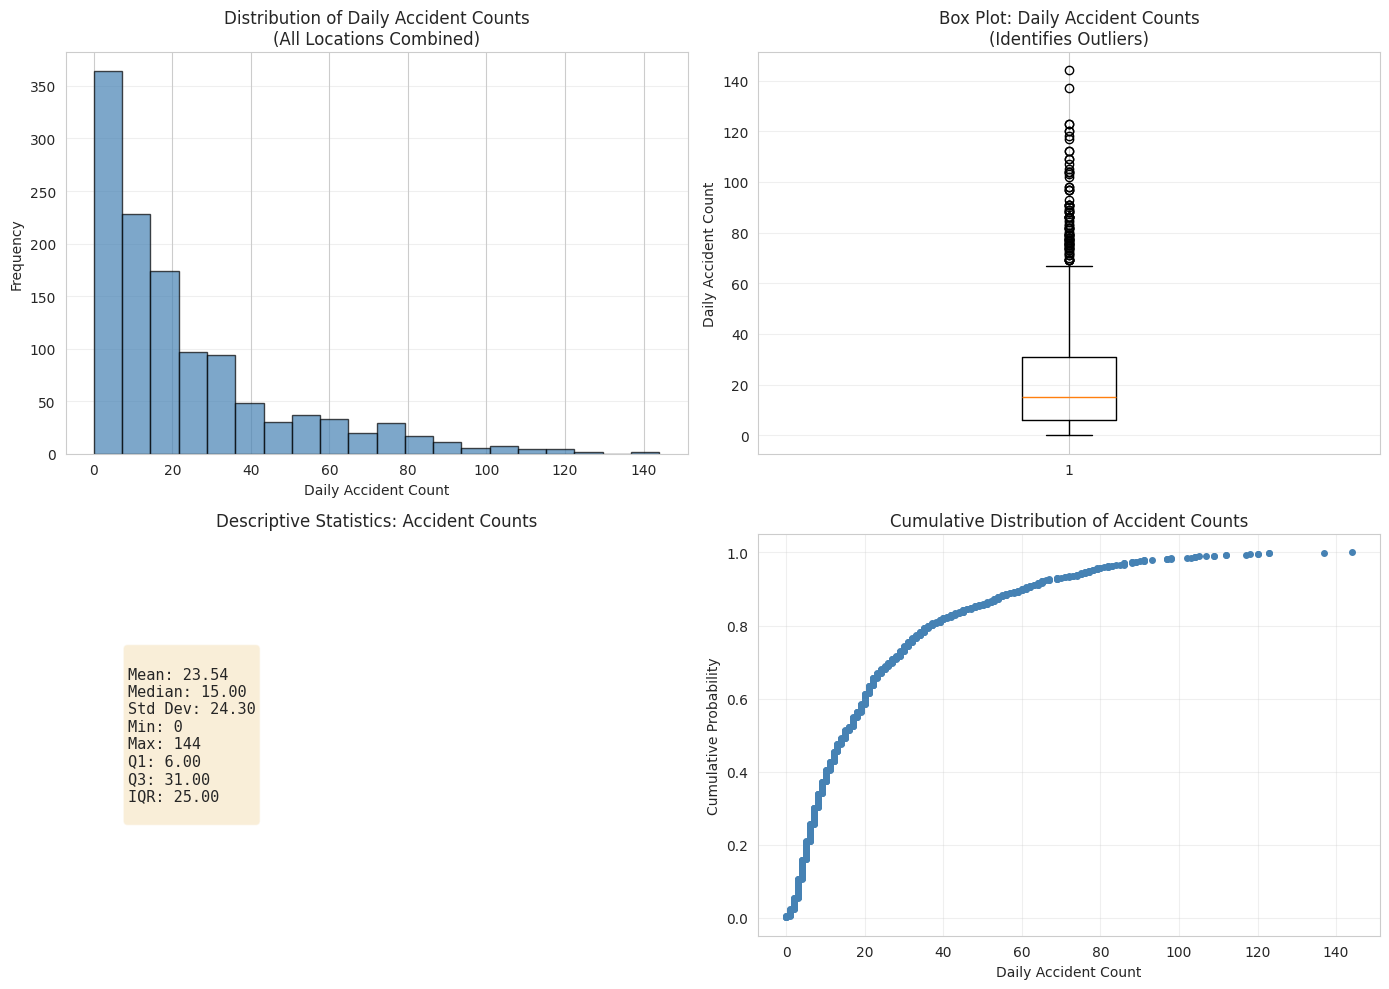

ACCIDENT COUNT STATISTICS
count    1206.000000
mean       23.539801
std        24.303537
min         0.000000
25%         6.000000
50%        15.000000
75%        31.000000
max       144.000000
Name: accident_count, dtype: float64


In [172]:
# Visualization 1: Accident Count Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of accident counts
axes[0, 0].hist(merged_df['accident_count'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Daily Accident Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Daily Accident Counts\n(All Locations Combined)')
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot to identify outliers
axes[0, 1].boxplot(merged_df['accident_count'], vert=True)
axes[0, 1].set_ylabel('Daily Accident Count')
axes[0, 1].set_title('Box Plot: Daily Accident Counts\n(Identifies Outliers)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Descriptive statistics
stats_text = f"""
Mean: {merged_df['accident_count'].mean():.2f}
Median: {merged_df['accident_count'].median():.2f}
Std Dev: {merged_df['accident_count'].std():.2f}
Min: {merged_df['accident_count'].min():.0f}
Max: {merged_df['accident_count'].max():.0f}
Q1: {merged_df['accident_count'].quantile(0.25):.2f}
Q3: {merged_df['accident_count'].quantile(0.75):.2f}
IQR: {merged_df['accident_count'].quantile(0.75) - merged_df['accident_count'].quantile(0.25):.2f}
"""
axes[1, 0].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center', 
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].axis('off')
axes[1, 0].set_title('Descriptive Statistics: Accident Counts')

# Cumulative distribution
sorted_accidents = np.sort(merged_df['accident_count'])
cumulative = np.arange(1, len(sorted_accidents) + 1) / len(sorted_accidents)
axes[1, 1].plot(sorted_accidents, cumulative, marker='.', linestyle='none', markersize=8, color='steelblue')
axes[1, 1].set_xlabel('Daily Accident Count')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution of Accident Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ACCIDENT COUNT STATISTICS")
print("="*80)
print(merged_df['accident_count'].describe())


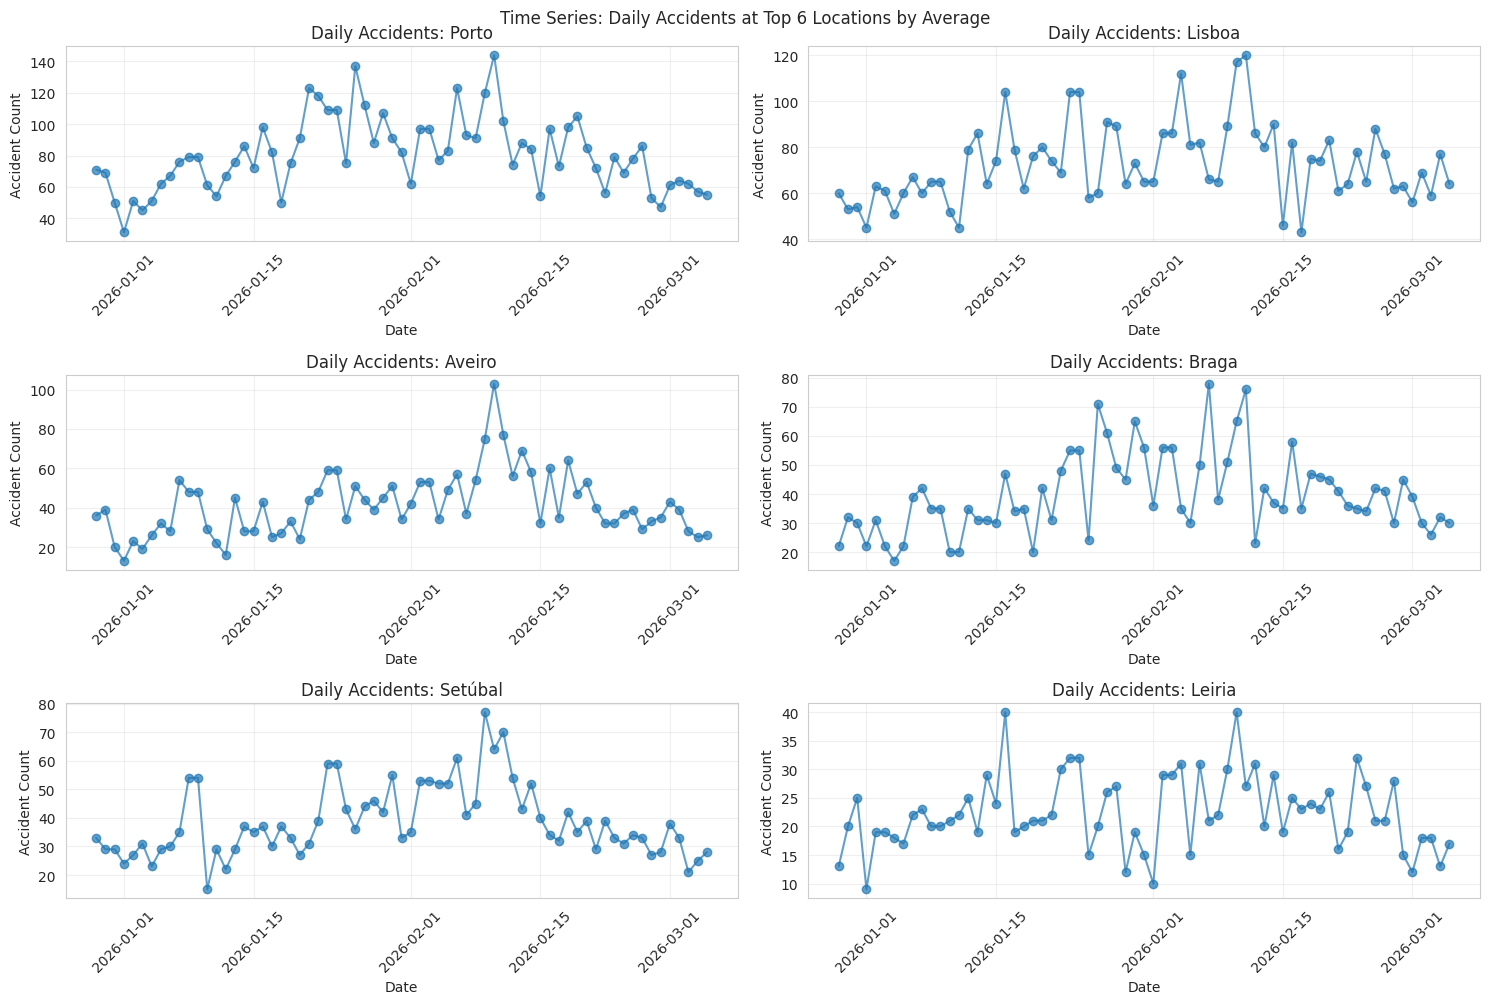

TOP 6 LOCATIONS BY AVERAGE DAILY ACCIDENTS
               mean        std  min  max  count
location                                       
Porto     80.298507  23.309521   31  144     67
Lisboa    72.641791  16.948855   43  120     67
Aveiro    41.194030  15.971792   13  103     67
Braga     39.611940  13.846513   17   78     67
Setúbal   38.641791  12.428830   15   77     67
Leiria    22.358209   6.496389    9   40     67


In [173]:
# Visualization 2: Time Series of Accidents by Location
# Select a subset of locations for clarity (top 6 by mean accidents)
top_locations = merged_df.groupby('location')['accident_count'].mean().nlargest(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, location in enumerate(top_locations):
    location_data = merged_df[merged_df['location'] == location].sort_values('date')
    axes[idx].plot(location_data['date'], location_data['accident_count'], marker='o', linestyle='-', label=location, alpha=0.7)
    axes[idx].set_title(f'Daily Accidents: {location}')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Accident Count')
    axes[idx].grid(alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Time Series: Daily Accidents at Top 6 Locations by Average', y=1.00, fontsize=12)
plt.show()

print("TOP 6 LOCATIONS BY AVERAGE DAILY ACCIDENTS")
print("="*80)
location_stats = merged_df.groupby('location')['accident_count'].agg(['mean', 'std', 'min', 'max', 'count'])
print(location_stats.sort_values('mean', ascending=False).head(6))


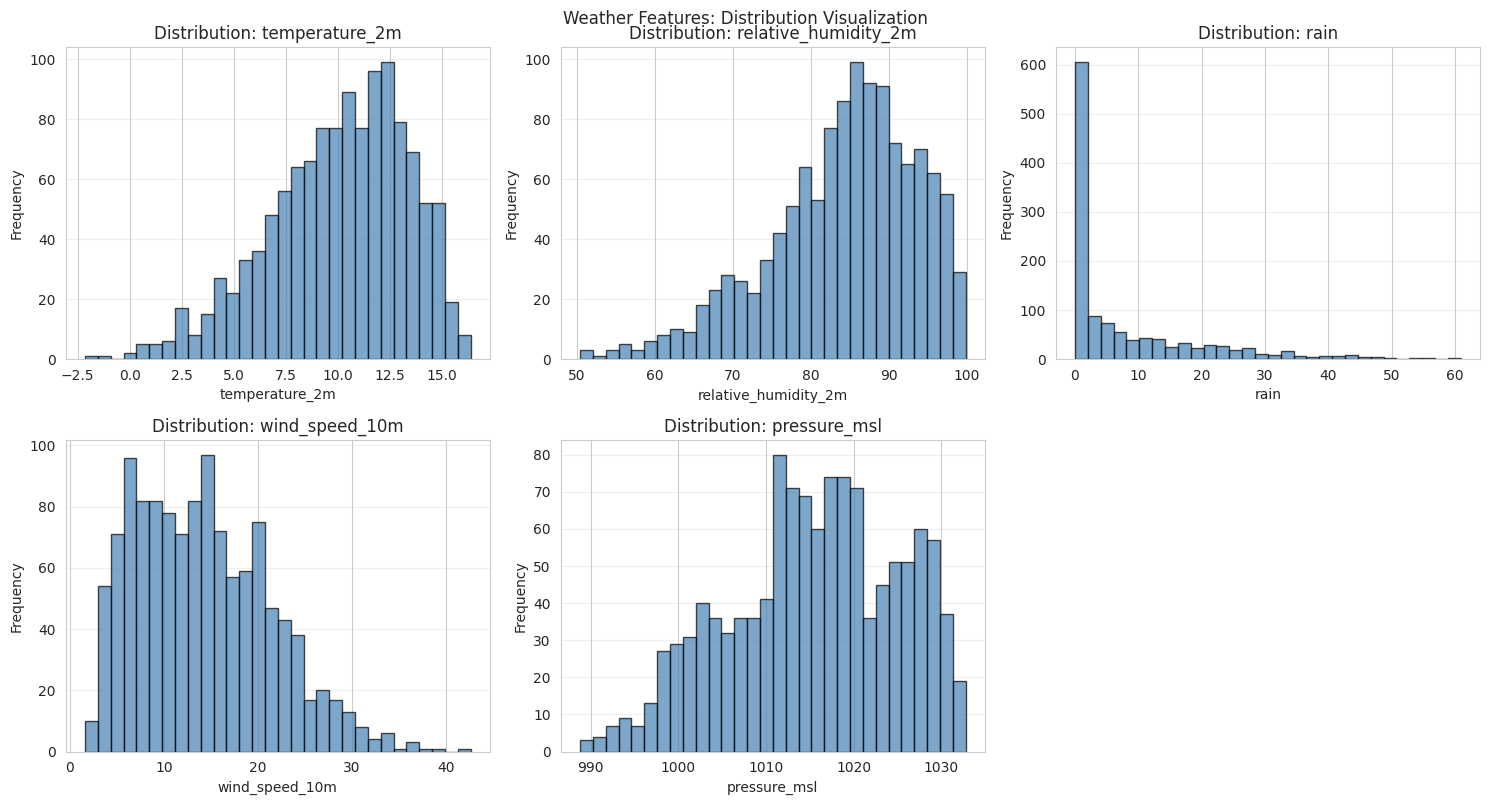

WEATHER FEATURES STATISTICS
       temperature_2m  relative_humidity_2m         rain  wind_speed_10m  \
count     1206.000000           1206.000000  1206.000000     1206.000000   
mean        10.068107             84.189849     8.019403       14.143619   
std          3.287970              9.422888    11.614916        7.166314   
min         -2.145833             50.375000     0.000000        1.625000   
25%          7.897917             78.750000     0.000000        8.236458   
50%         10.493750             85.645833     2.000000       13.529167   
75%         12.529167             91.281250    12.200000       19.238542   
max         16.404167             99.875000    60.900000       42.604167   

       pressure_msl  
count   1206.000000  
mean    1015.388740  
std        9.665182  
min      988.775000  
25%     1008.973958  
50%     1015.927083  
75%     1023.408333  
max     1032.775000  


In [174]:
# Visualization 3: Weather Feature Distributions
# Select key weather features for inspection
key_features = ['temperature_2m', 'relative_humidity_2m', 'rain', 'wind_speed_10m', 'pressure_msl']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    axes[idx].hist(merged_df[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution: {feature}')
    axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.suptitle('Weather Features: Distribution Visualization', y=1.00, fontsize=12)
plt.show()

print("WEATHER FEATURES STATISTICS")
print("="*80)
print(merged_df[key_features].describe())


GLOBAL CORRELATION WITH ACCIDENT COUNT (Top Features)
surface_pressure       0.422992
temperature_2m         0.310885
dew_point_2m           0.278143
rain                   0.194143
wind_gusts_10m         0.160684
wind_speed_100m        0.159183
wind_speed_10m         0.154468
cloud_cover_mid        0.108195
wind_direction_100m    0.103303
wind_direction_10m     0.096096
Name: accident_count, dtype: float64

BOTTOM FEATURES (Negative Correlation)
cloud_cover             0.028843
cloud_cover_low        -0.024611
relative_humidity_2m   -0.033377
snow_fall              -0.057585
pressure_msl           -0.078025
Name: accident_count, dtype: float64


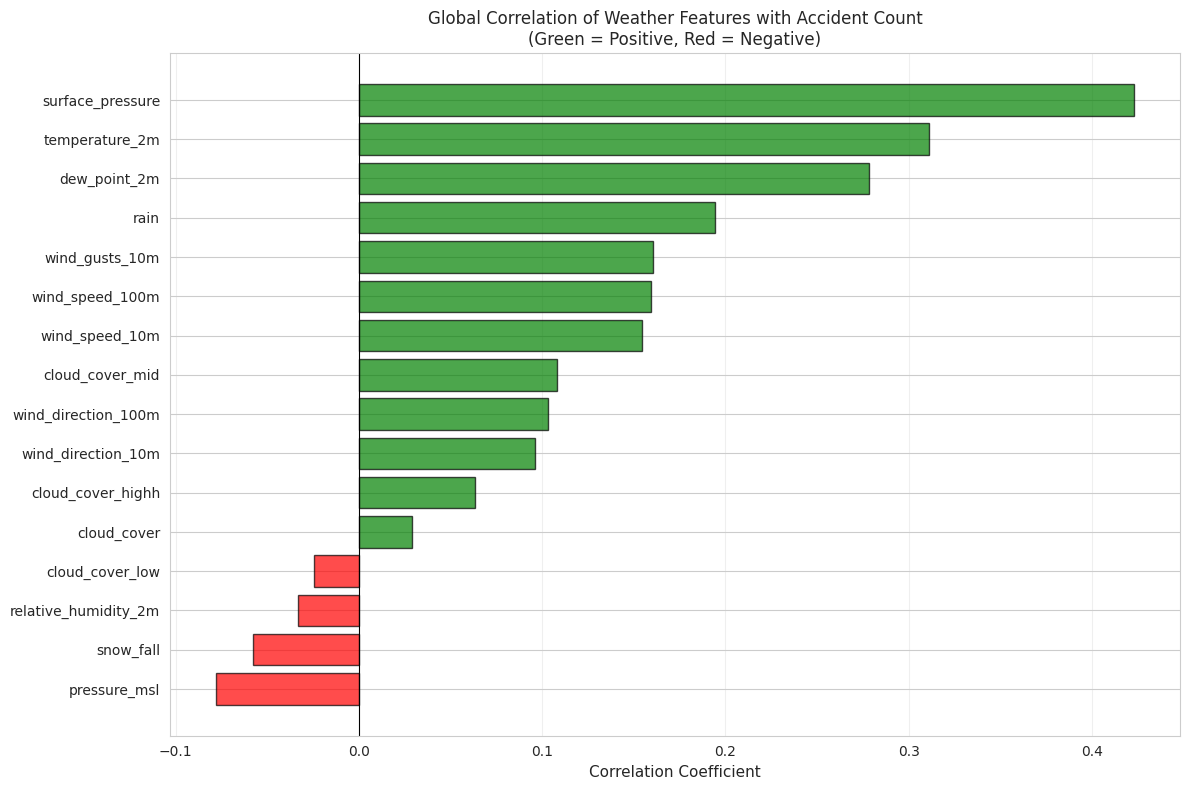

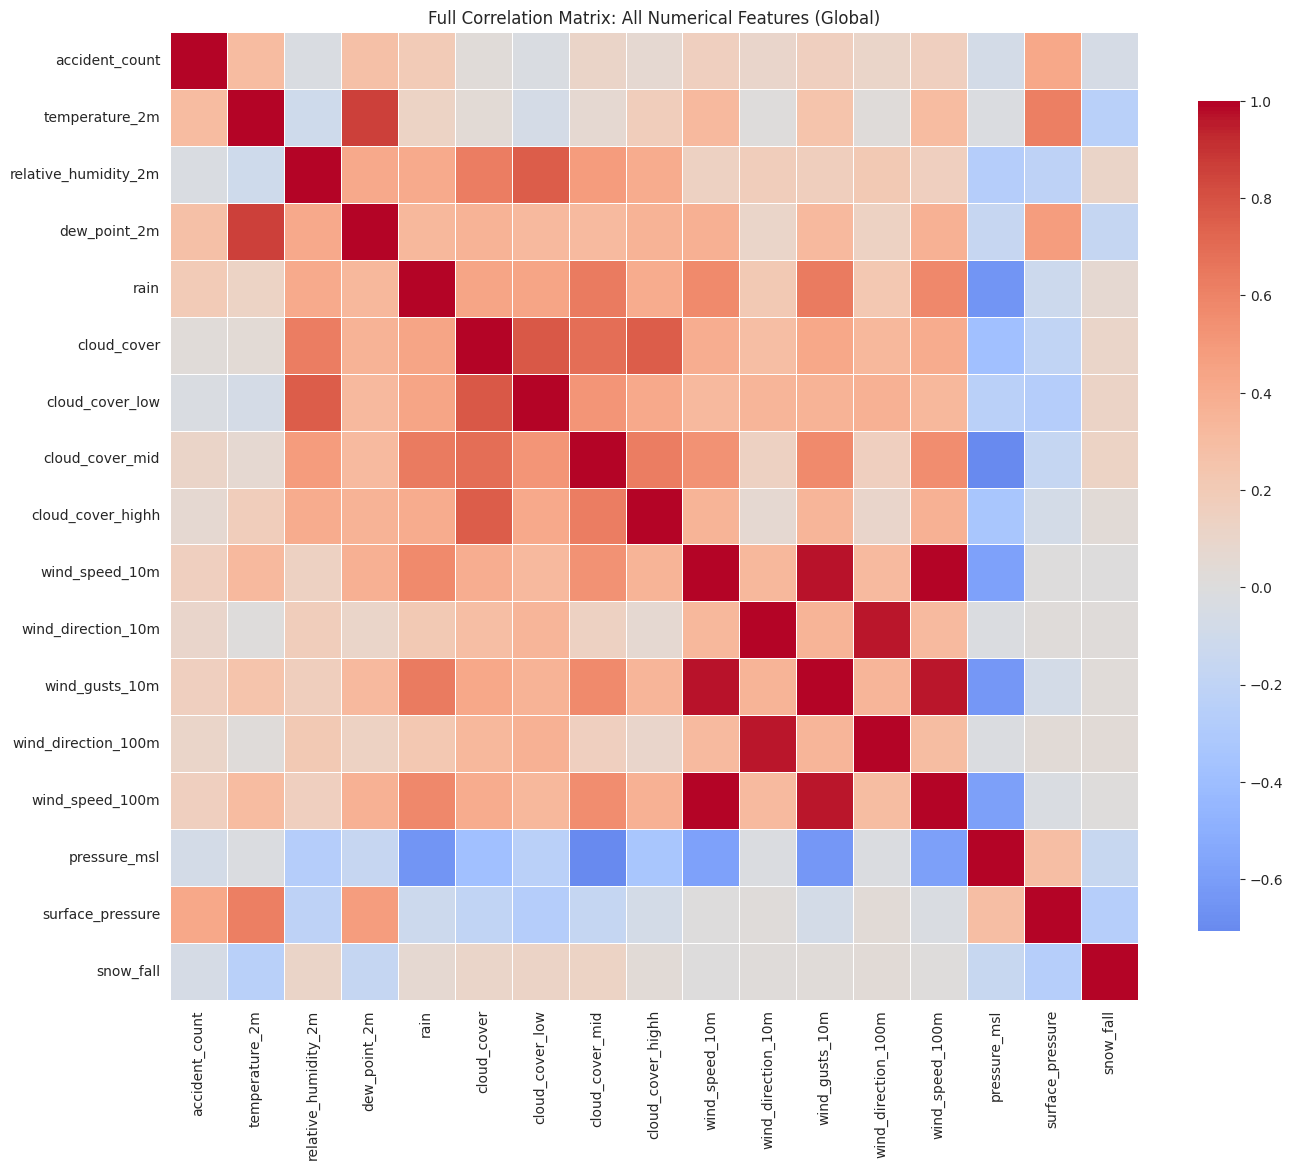


INTERPRETATION NOTE:
This section is descriptive only. Strong global |r| can be confounded by regional baseline differences.
Use Phase 3B (global vs regional / within-region decomposition) before selecting features.


In [175]:
# Visualization 4: Global Correlation Overview (Weather Features vs Accidents)
# Note: this is a global view and may include regional composition effects.

# Select numerical columns (exclude location and date)
numerical_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
correlation_matrix = merged_df[numerical_cols].corr()

# Extract correlations with accident_count
accident_correlations = correlation_matrix['accident_count'].drop('accident_count').sort_values(ascending=False)

print("GLOBAL CORRELATION WITH ACCIDENT COUNT (Top Features)")
print("="*80)
print(accident_correlations.head(10))
print("\nBOTTOM FEATURES (Negative Correlation)")
print(accident_correlations.tail(5))

# Visualize correlation bar chart
fig, ax = plt.subplots(figsize=(12, 8))
corr_df = pd.DataFrame(accident_correlations).sort_values('accident_count')
colors = ['red' if x < 0 else 'green' for x in corr_df['accident_count']]

ax.barh(range(len(corr_df)), corr_df['accident_count'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df.index, fontsize=10)
ax.set_xlabel('Correlation Coefficient', fontsize=11)
ax.set_title('Global Correlation of Weather Features with Accident Count\n(Green = Positive, Red = Negative)', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Full correlation matrix visualization (all numerical features)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Full Correlation Matrix: All Numerical Features (Global)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION NOTE:")
print("="*80)
print("This section is descriptive only. Strong global |r| can be confounded by regional baseline differences.")
print("Use Phase 3B (global vs regional / within-region decomposition) before selecting features.")

## Phase 3B: Correlation Decomposition (Global vs Regional)

Goal: understand whether global weather-accident correlations are true within-region weather effects, or mostly composition effects driven by regional baseline traffic/population intensity.

GLOBAL VS REGION CORRELATION SUMMARY
                      global_corr  median_region_corr  mean_region_corr  share_positive_regions  share_negative_regions  global_minus_median
surface_pressure            0.423              -0.130            -0.158                   0.278                   0.722                0.553
temperature_2m              0.311               0.000             0.004                   0.500                   0.500                0.310
rain                        0.194               0.311             0.278                   0.833                   0.167               -0.117
wind_gusts_10m              0.161               0.224             0.223                   0.833                   0.167               -0.064
cloud_cover_low            -0.025               0.152             0.159                   0.778                   0.222               -0.177
relative_humidity_2m       -0.033               0.095             0.126                   0.667                   0.3

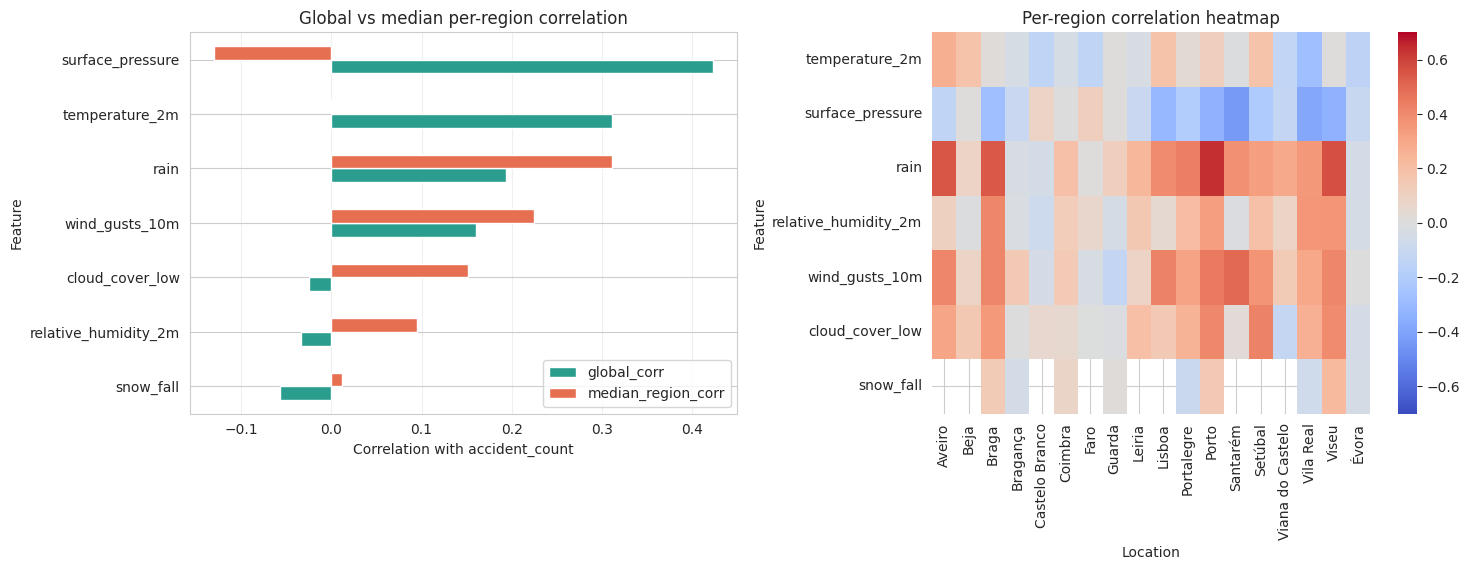

In [176]:
# Diagnostic 1: Global vs per-region correlation map
selected_features = [
    'temperature_2m', 'surface_pressure', 'rain', 'relative_humidity_2m',
    'wind_gusts_10m', 'cloud_cover_low', 'snow_fall'
 ]
selected_features = [f for f in selected_features if f in merged_df.columns]

global_corr = merged_df[selected_features + ['accident_count']].corr()['accident_count'].drop('accident_count')

locations = sorted(merged_df['location'].unique())
region_corr = pd.DataFrame(index=selected_features, columns=locations, dtype=float)
for loc in locations:
    loc_df = merged_df[merged_df['location'] == loc]
    for feat in selected_features:
        if loc_df[feat].nunique() <= 1:
            region_corr.loc[feat, loc] = np.nan
        else:
            region_corr.loc[feat, loc] = loc_df[[feat, 'accident_count']].corr().iloc[0, 1]

region_summary = pd.DataFrame({
    'global_corr': global_corr,
    'median_region_corr': region_corr.median(axis=1),
    'mean_region_corr': region_corr.mean(axis=1),
    'share_positive_regions': (region_corr > 0).mean(axis=1),
    'share_negative_regions': (region_corr < 0).mean(axis=1)
}).sort_values('global_corr', ascending=False)
region_summary['global_minus_median'] = region_summary['global_corr'] - region_summary['median_region_corr']

print('GLOBAL VS REGION CORRELATION SUMMARY')
print('=' * 90)
print(region_summary.round(3).to_string())

divergence = region_summary.reindex(region_summary['global_minus_median'].abs().sort_values(ascending=False).index)
print('\nLARGEST GLOBAL-REGIONAL DIVERGENCES')
print('=' * 90)
print(divergence[['global_corr', 'median_region_corr', 'global_minus_median']].head(7).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

plot_df = region_summary[['global_corr', 'median_region_corr']].sort_values('global_corr')
plot_df.plot(kind='barh', ax=axes[0], color=['#2a9d8f', '#e76f51'])
axes[0].set_title('Global vs median per-region correlation')
axes[0].set_xlabel('Correlation with accident_count')
axes[0].set_ylabel('Feature')
axes[0].grid(axis='x', alpha=0.3)

sns.heatmap(region_corr, cmap='coolwarm', center=0, vmin=-0.7, vmax=0.7, ax=axes[1])
axes[1].set_title('Per-region correlation heatmap')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

CORRELATION DECOMPOSITION (GLOBAL / BETWEEN / WITHIN)
                  global_corr  between_region_corr  within_region_corr  between_minus_within
temperature_2m         0.3109               0.4739              0.0449                0.4290
surface_pressure       0.4230               0.5041             -0.1762                0.6803
rain                   0.1941               0.2744              0.3465               -0.0721


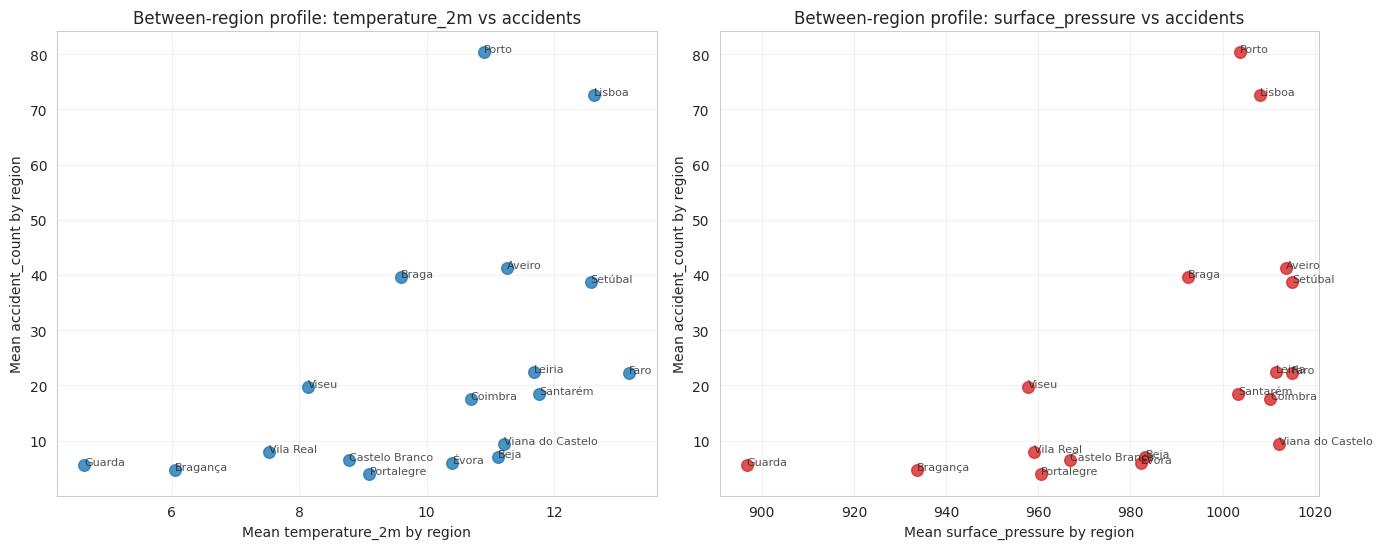

In [177]:
# Diagnostic 2: Between-region vs within-region decomposition for key concerns
focus_features = [f for f in ['temperature_2m', 'surface_pressure', 'rain'] if f in merged_df.columns]

# Between-region effect: correlate region means (proxy for long-run profile differences)
region_means = merged_df.groupby('location')[focus_features + ['accident_count']].mean()
between_corr = region_means.corr()['accident_count'].drop('accident_count')

# Within-region effect: remove each region baseline and correlate residual variation
demeaned_df = merged_df.copy()
for col in focus_features + ['accident_count']:
    demeaned_df[col] = demeaned_df[col] - demeaned_df.groupby('location')[col].transform('mean')
within_corr = demeaned_df[focus_features + ['accident_count']].corr()['accident_count'].drop('accident_count')

global_focus = merged_df[focus_features + ['accident_count']].corr()['accident_count'].drop('accident_count')

decomp_table = pd.DataFrame({
    'global_corr': global_focus,
    'between_region_corr': between_corr,
    'within_region_corr': within_corr
}).round(4)
decomp_table['between_minus_within'] = (
    decomp_table['between_region_corr'] - decomp_table['within_region_corr']
).round(4)

print('CORRELATION DECOMPOSITION (GLOBAL / BETWEEN / WITHIN)')
print('=' * 90)
print(decomp_table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, feat, color in zip(axes, ['temperature_2m', 'surface_pressure'], ['#1f77b4', '#d62728']):
    if feat not in region_means.columns:
        ax.axis('off')
        continue
    ax.scatter(region_means[feat], region_means['accident_count'], s=70, alpha=0.8, color=color)
    for loc, row in region_means.iterrows():
        ax.text(row[feat], row['accident_count'], loc, fontsize=8, alpha=0.8)
    ax.set_xlabel(f'Mean {feat} by region')
    ax.set_ylabel('Mean accident_count by region')
    ax.set_title(f'Between-region profile: {feat} vs accidents')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

SNOW CORRELATION DIAGNOSTICS
Global corr(snow_fall, accident_count): -0.0576
Locations with any snow days: 9 / 18
Weighted snow-day minus non-snow-day delta (within snow locations): 2.2681
Controlled delta (within location + temperature bin): 2.7308

SNOW PRESENCE VS BASELINE ACCIDENTS BY LOCATION
                  mean_accidents  snow_days  snow_rate  mean_snow_amount
location                                                                
Porto                     80.299          1      0.015             0.015
Lisboa                    72.642          0      0.000             0.000
Aveiro                    41.194          0      0.000             0.000
Braga                     39.612          1      0.015             0.015
Setúbal                   38.642          0      0.000             0.000
Leiria                    22.358          0      0.000             0.000
Faro                      22.269          0      0.000             0.000
Viseu                     19.657          2 

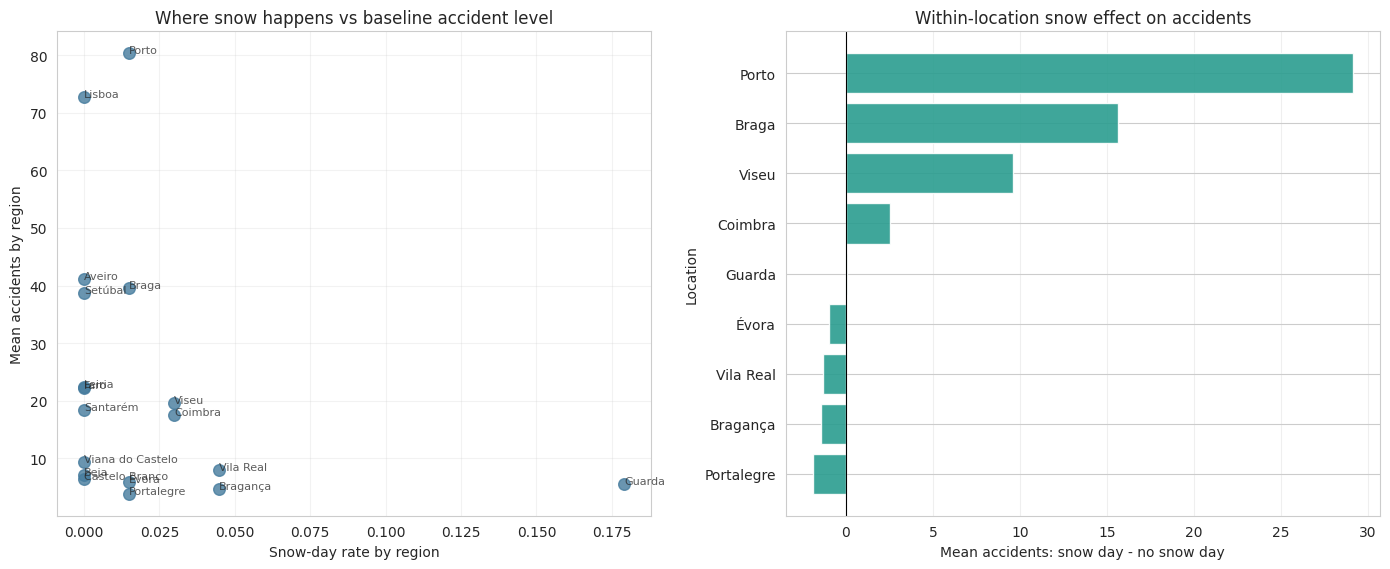

In [178]:
# Diagnostic 3: Snow paradox check (global negative vs local effect)
snow_global_corr = merged_df[['snow_fall', 'accident_count']].corr().iloc[0, 1]

loc_snow = merged_df.groupby('location').agg(
    mean_accidents=('accident_count', 'mean'),
    snow_days=('snow_fall', lambda s: int((s > 0).sum())),
    snow_rate=('snow_fall', lambda s: (s > 0).mean()),
    mean_snow_amount=('snow_fall', 'mean')
).sort_values('mean_accidents', ascending=False)

snow_locs = loc_snow[loc_snow['snow_days'] > 0].index.tolist()

snow_effect_rows = []
for loc in snow_locs:
    d = merged_df[merged_df['location'] == loc].copy()
    snow_days = d[d['snow_fall'] > 0]['accident_count']
    no_snow_days = d[d['snow_fall'] == 0]['accident_count']
    if len(snow_days) == 0 or len(no_snow_days) == 0:
        continue
    snow_effect_rows.append({
        'location': loc,
        'n_snow': len(snow_days),
        'n_no_snow': len(no_snow_days),
        'mean_acc_snow_days': snow_days.mean(),
        'mean_acc_no_snow_days': no_snow_days.mean(),
        'delta_snow_minus_no_snow': snow_days.mean() - no_snow_days.mean()
    })

snow_effect_df = pd.DataFrame(snow_effect_rows).sort_values('delta_snow_minus_no_snow', ascending=False)

# Weighted within-snow-location effect
if len(snow_effect_df) > 0:
    weighted_delta = np.average(
        snow_effect_df['delta_snow_minus_no_snow'],
        weights=snow_effect_df['n_snow']
    )
else:
    weighted_delta = np.nan

# Snow effect controlling for location and temperature bin
snow_control_df = merged_df.copy()
snow_control_df['temp_bin'] = pd.qcut(
    snow_control_df['temperature_2m'], q=4, duplicates='drop', labels=False
)

control_rows = []
for (loc, tb), g in snow_control_df.groupby(['location', 'temp_bin']):
    a = g[g['snow_fall'] > 0]['accident_count']
    b = g[g['snow_fall'] == 0]['accident_count']
    if len(a) > 0 and len(b) > 0:
        control_rows.append({
            'location': loc,
            'temp_bin': tb,
            'n_snow': len(a),
            'delta': a.mean() - b.mean()
        })

control_df = pd.DataFrame(control_rows)
controlled_delta = np.average(control_df['delta'], weights=control_df['n_snow']) if len(control_df) else np.nan

print('SNOW CORRELATION DIAGNOSTICS')
print('=' * 90)
print(f'Global corr(snow_fall, accident_count): {snow_global_corr:.4f}')
print(f'Locations with any snow days: {len(snow_locs)} / {loc_snow.shape[0]}')
print(f'Weighted snow-day minus non-snow-day delta (within snow locations): {weighted_delta:.4f}')
print(f'Controlled delta (within location + temperature bin): {controlled_delta:.4f}')

print('\nSNOW PRESENCE VS BASELINE ACCIDENTS BY LOCATION')
print('=' * 90)
print(loc_snow[['mean_accidents', 'snow_days', 'snow_rate', 'mean_snow_amount']].round(3).to_string())

if len(snow_effect_df) > 0:
    print('\nWITHIN-LOCATION SNOW EFFECT (snow day - no snow day)')
    print('=' * 90)
    print(snow_effect_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

axes[0].scatter(loc_snow['snow_rate'], loc_snow['mean_accidents'], s=70, alpha=0.8, color='#457b9d')
for loc, row in loc_snow.iterrows():
    axes[0].text(row['snow_rate'], row['mean_accidents'], loc, fontsize=8, alpha=0.75)
axes[0].set_xlabel('Snow-day rate by region')
axes[0].set_ylabel('Mean accidents by region')
axes[0].set_title('Where snow happens vs baseline accident level')
axes[0].grid(alpha=0.25)

if len(snow_effect_df) > 0:
    plot_snow = snow_effect_df.sort_values('delta_snow_minus_no_snow')
    axes[1].barh(plot_snow['location'], plot_snow['delta_snow_minus_no_snow'], color='#2a9d8f', alpha=0.9)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('Within-location snow effect on accidents')
    axes[1].set_xlabel('Mean accidents: snow day - no snow day')
    axes[1].set_ylabel('Location')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No locations with comparable snow/non-snow days', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## Phase 3C: Extra Visual Corroboration of Simpson's Paradox

Goal: visually compare pooled global trends against within-region (demeaned) trends for the most confounded features.

If a feature is truly confounded, the global slope and within-region slope can diverge strongly (or even flip sign).

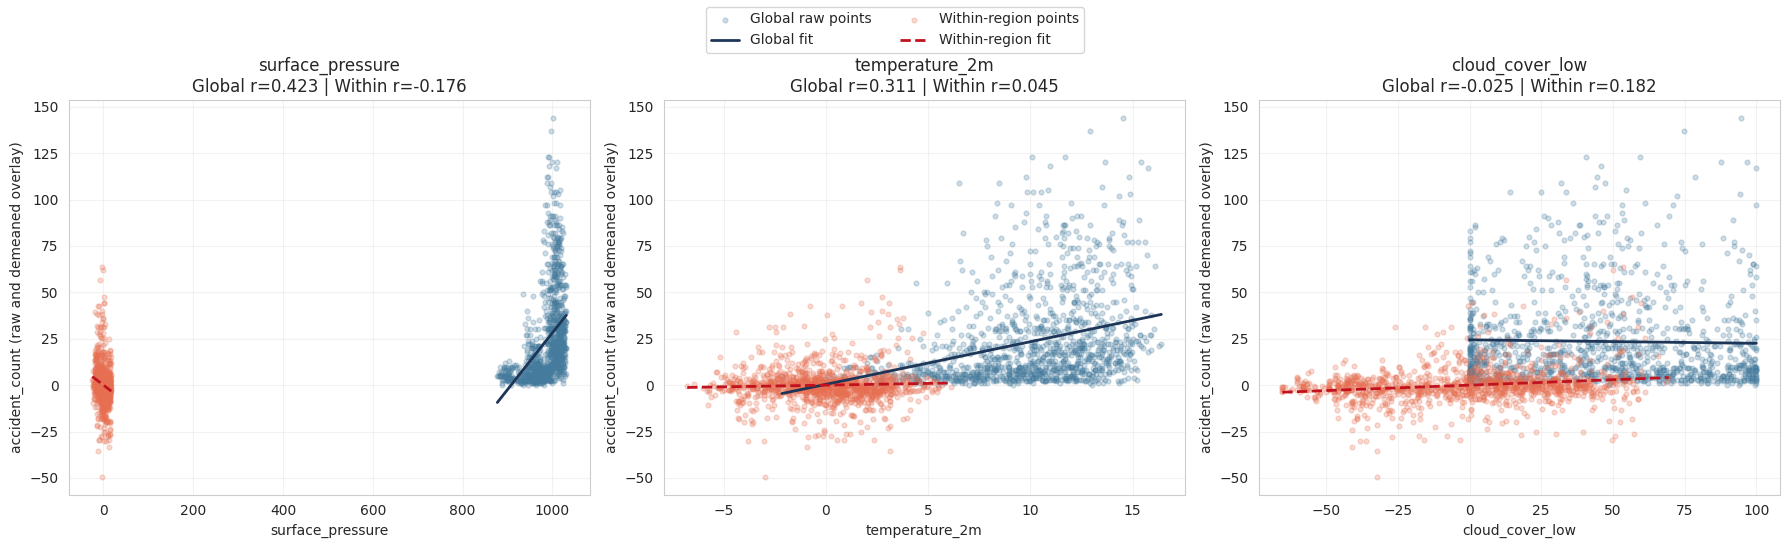

GLOBAL VS WITHIN-REGION TREND CHECK (TOP CONFODED FEATURES)
                  global_corr  within_corr  global_slope  within_slope  sign_flip
feature                                                                          
surface_pressure       0.4230      -0.1762        0.3060       -0.1850       True
temperature_2m         0.3109       0.0449        2.2980        0.1846      False
cloud_cover_low       -0.0246       0.1824       -0.0188        0.0585       True


In [179]:
# Diagnostic 4: Global vs within-region scatter for top confounded features
if 'region_summary' not in globals():
    temp_features = [c for c in merged_df.select_dtypes(include=[np.number]).columns if c != 'accident_count']
    _global_corr = merged_df[temp_features + ['accident_count']].corr()['accident_count'].drop('accident_count')
    _region_corr = pd.DataFrame(index=temp_features, columns=sorted(merged_df['location'].unique()), dtype=float)
    for _loc in sorted(merged_df['location'].unique()):
        _df = merged_df[merged_df['location'] == _loc]
        for _feat in temp_features:
            _region_corr.loc[_feat, _loc] = np.nan if _df[_feat].nunique() <= 1 else _df[[_feat, 'accident_count']].corr().iloc[0, 1]
    region_summary = pd.DataFrame({
        'global_corr': _global_corr,
        'median_region_corr': _region_corr.median(axis=1)
    })
    region_summary['global_minus_median'] = region_summary['global_corr'] - region_summary['median_region_corr']

confounded_feats = region_summary['global_minus_median'].abs().sort_values(ascending=False).head(3).index.tolist()
confounded_feats = [f for f in confounded_feats if f in merged_df.columns]

if len(confounded_feats) == 0:
    print('No confounded features available for plotting.')
else:
    fig, axes = plt.subplots(1, len(confounded_feats), figsize=(6 * len(confounded_feats), 5.5))
    if len(confounded_feats) == 1:
        axes = [axes]

    rows = []
    for ax, feat in zip(axes, confounded_feats):
        gdf = merged_df[[feat, 'accident_count', 'location']].dropna().copy()

        # Global correlation and slope
        g_corr = gdf[[feat, 'accident_count']].corr().iloc[0, 1]
        g_x = gdf[feat].to_numpy()
        g_y = gdf['accident_count'].to_numpy()
        if len(np.unique(g_x)) > 1:
            g_slope, g_inter = np.polyfit(g_x, g_y, 1)
        else:
            g_slope, g_inter = 0.0, g_y.mean()

        # Within-region (demeaned) correlation and slope
        wdf = gdf.copy()
        wdf['x_within'] = wdf[feat] - wdf.groupby('location')[feat].transform('mean')
        wdf['y_within'] = wdf['accident_count'] - wdf.groupby('location')['accident_count'].transform('mean')
        w_corr = wdf[['x_within', 'y_within']].corr().iloc[0, 1]
        w_x = wdf['x_within'].to_numpy()
        w_y = wdf['y_within'].to_numpy()
        if len(np.unique(w_x)) > 1:
            w_slope, w_inter = np.polyfit(w_x, w_y, 1)
        else:
            w_slope, w_inter = 0.0, w_y.mean()

        # Plot global trend (raw)
        ax.scatter(g_x, g_y, s=12, alpha=0.25, color='#457b9d', label='Global raw points')
        gx_line = np.linspace(g_x.min(), g_x.max(), 100)
        ax.plot(gx_line, g_slope * gx_line + g_inter, color='#1d3557', linewidth=2, label='Global fit')

        # Plot within-region trend (demeaned)
        ax.scatter(w_x, w_y, s=12, alpha=0.25, color='#e76f51', label='Within-region points')
        wx_line = np.linspace(w_x.min(), w_x.max(), 100)
        ax.plot(wx_line, w_slope * wx_line + w_inter, color='#c1121f', linewidth=2, linestyle='--', label='Within-region fit')

        ax.set_title(f'{feat}\nGlobal r={g_corr:.3f} | Within r={w_corr:.3f}')
        ax.set_xlabel(feat)
        ax.set_ylabel('accident_count (raw and demeaned overlay)')
        ax.grid(alpha=0.25)

        rows.append({
            'feature': feat,
            'global_corr': g_corr,
            'within_corr': w_corr,
            'global_slope': g_slope,
            'within_slope': w_slope,
            'sign_flip': np.sign(g_corr) != np.sign(w_corr)
        })

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    paradox_table = pd.DataFrame(rows).set_index('feature').round(4)
    print('GLOBAL VS WITHIN-REGION TREND CHECK (TOP CONFODED FEATURES)')
    print('=' * 90)
    print(paradox_table.to_string())

## Phase 4: Feature Engineering (Weather Effect with Proper Controls)

We keep weather as the core explanatory signal, while adding control variables that prevent false attribution:
- Temporal controls (`day_of_week`, `month`, `is_weekend`) capture normal traffic cycles.
- Spatial control (`location` one-hot) captures baseline regional differences.
- Snow is represented as `has_snow` (0/1), matching the available data values.

In [180]:
# Build modeling table with controlled features
model_df = merged_df.copy().sort_values(['date', 'location']).reset_index(drop=True)

# Temporal controls
model_df['day_of_week'] = model_df['date'].dt.dayofweek
model_df['month'] = model_df['date'].dt.month
model_df['is_weekend'] = (model_df['day_of_week'] >= 5).astype(int)

# Snow as binary indicator (dataset effectively contains 0/1)
model_df['has_snow'] = (model_df['snow_fall'] > 0).astype(int)

# Weather features (exclude target/date and keep numerics)
exclude_cols = {'accident_count', 'date', 'location', 'snow_fall'}
weather_cols = [
    c for c in model_df.select_dtypes(include=[np.number]).columns
    if c not in exclude_cols and c not in {'day_of_week', 'month', 'is_weekend', 'has_snow'}
]

# Keep core weather set if available, otherwise fallback to numeric weather columns
core_cols = [
    'temperature_2m', 'relative_humidity_2m', 'rain', 'wind_speed_10m',
    'wind_gusts_10m', 'pressure_msl', 'surface_pressure',
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_highh'
]
core_cols = [c for c in core_cols if c in model_df.columns]
weather_cols = sorted(set(core_cols) | set(weather_cols))

base_feature_cols = weather_cols + ['has_snow', 'day_of_week', 'month', 'is_weekend']

# Global model features include one-hot location to account for baseline regional differences
model_df_global = pd.get_dummies(
    model_df[['location', 'date', 'accident_count'] + base_feature_cols],
    columns=['location'],
    drop_first=False,
    dtype=float
)

global_features = [c for c in model_df_global.columns if c not in ['date', 'accident_count']]
regional_features = base_feature_cols.copy()

print('FEATURE ENGINEERING SUMMARY')
print('=' * 90)
print(f'Rows: {model_df.shape[0]} | Locations: {model_df["location"].nunique()} | Dates: {model_df["date"].nunique()}')
print(f'Weather features used: {len(weather_cols)}')
print(f'Temporal controls: day_of_week, month, is_weekend')
print(f'Snow feature: has_snow (binary)')
print(f'Global feature count (with one-hot location): {len(global_features)}')
print(f'Regional feature count: {len(regional_features)}')
print('\nSample engineered rows:')
print(model_df[['location', 'date', 'accident_count', 'has_snow', 'day_of_week', 'is_weekend']].head(8).to_string(index=False))

FEATURE ENGINEERING SUMMARY
Rows: 1206 | Locations: 18 | Dates: 67
Weather features used: 15
Temporal controls: day_of_week, month, is_weekend
Snow feature: has_snow (binary)
Global feature count (with one-hot location): 37
Regional feature count: 19

Sample engineered rows:
      location       date  accident_count  has_snow  day_of_week  is_weekend
        Aveiro 2025-12-29              36         0            0           0
          Beja 2025-12-29               7         0            0           0
         Braga 2025-12-29              22         0            0           0
      Bragança 2025-12-29               7         0            0           0
Castelo Branco 2025-12-29              11         0            0           0
       Coimbra 2025-12-29              12         0            0           0
          Faro 2025-12-29              28         0            0           0
        Guarda 2025-12-29               9         0            0           0


## Phase 5: Modeling Comparison (Global vs Per-Region)

We compare:
- A single global linear model with one-hot `location` controls.
- Independent linear models trained per location.

Split strategy remains chronological to avoid leakage from future days.

In [181]:
# Train/test split (chronological): keep the latest days for test
from sklearn.linear_model import LinearRegression

unique_dates = np.array(sorted(model_df['date'].unique()))
test_days = max(10, int(round(0.15 * len(unique_dates))))
split_date = unique_dates[-test_days]

train_mask = model_df['date'] < split_date
test_mask = model_df['date'] >= split_date

train_df = model_df[train_mask].copy()
test_df = model_df[test_mask].copy()
train_global = model_df_global[model_df_global['date'] < split_date].copy()
test_global = model_df_global[model_df_global['date'] >= split_date].copy()

# Underestimation penalty control: residual-quantile safety uplift
# Safer defaults avoid extreme overprediction when UNDER_PENALTY is accidentally high.
if 'UNDER_PENALTY' not in globals():
    UNDER_PENALTY = 0.6

UNDER_PENALTY = float(UNDER_PENALTY)
if not (0.0 < UNDER_PENALTY < 1.0):
    UNDER_PENALTY = 0.6

MAX_GLOBAL_UPLIFT = 2.5
MAX_REGION_UPLIFT = 2.0

def learn_uplift(y_true, y_pred, q, cap):
    resid = y_true - y_pred
    pos_resid = resid[resid > 0]
    if len(pos_resid) == 0:
        return 0.0
    return float(min(np.quantile(pos_resid, q), cap))

# Global model (with location one-hot)
global_model = LinearRegression()
X_train_g = train_global[global_features]
y_train_g = train_global['accident_count']
X_test_g = test_global[global_features]

# Calibrate uplift on the latest portion of train set
train_unique_dates = np.array(sorted(train_global['date'].unique()))
calib_days = max(7, int(round(0.2 * len(train_unique_dates))))
calib_start = train_unique_dates[-calib_days]

inner_train_global = train_global[train_global['date'] < calib_start]
calib_global = train_global[train_global['date'] >= calib_start]

if len(inner_train_global) > 0 and len(calib_global) > 0:
    calib_global_model = LinearRegression()
    calib_global_model.fit(inner_train_global[global_features], inner_train_global['accident_count'])
    calib_pred = np.maximum(0, calib_global_model.predict(calib_global[global_features]))
    global_uplift = learn_uplift(
        calib_global['accident_count'].to_numpy(),
        calib_pred,
        UNDER_PENALTY,
        MAX_GLOBAL_UPLIFT
    )
else:
    global_uplift = 0.0

global_model.fit(X_train_g, y_train_g)
global_pred_raw = np.maximum(0, global_model.predict(X_test_g))
global_pred = global_pred_raw + global_uplift

# Regional models (one model per location)
regional_preds = []
for loc in sorted(test_df['location'].unique()):
    loc_train = train_df[train_df['location'] == loc].copy()
    loc_test = test_df[test_df['location'] == loc].copy()
    if len(loc_test) == 0:
        continue

    # If not enough training data, fallback to location historical mean
    if len(loc_train) < 8:
        base_mean = loc_train['accident_count'].mean() if len(loc_train) > 0 else train_df['accident_count'].mean()
        pred_raw = np.repeat(base_mean, len(loc_test))
        uplift_r = 0.0
    else:
        # Per-region underestimation-aware calibration
        region_dates = np.array(sorted(loc_train['date'].unique()))
        region_calib_days = max(3, int(round(0.2 * len(region_dates))))
        region_calib_start = region_dates[-region_calib_days]

        loc_inner_train = loc_train[loc_train['date'] < region_calib_start]
        loc_calib = loc_train[loc_train['date'] >= region_calib_start]

        model_r = LinearRegression()
        if len(loc_inner_train) > 0 and len(loc_calib) > 0:
            model_r.fit(loc_inner_train[regional_features], loc_inner_train['accident_count'])
            calib_pred_r = np.maximum(0, model_r.predict(loc_calib[regional_features]))
            uplift_r = learn_uplift(
                loc_calib['accident_count'].to_numpy(),
                calib_pred_r,
                UNDER_PENALTY,
                MAX_REGION_UPLIFT
            )
        else:
            uplift_r = 0.0

        # Fit final per-region model on full regional train slice
        model_r.fit(loc_train[regional_features], loc_train['accident_count'])
        pred_raw = np.maximum(0, model_r.predict(loc_test[regional_features]))

    loc_test = loc_test.copy()
    loc_test['pred_regional_raw'] = pred_raw
    loc_test['pred_regional'] = pred_raw + uplift_r
    regional_preds.append(loc_test[['location', 'date', 'pred_regional_raw', 'pred_regional']])

regional_pred_df = pd.concat(regional_preds, ignore_index=True)

# Evaluation frame
eval_df = test_df[['location', 'date', 'accident_count']].copy().reset_index(drop=True)
eval_df['pred_global_raw'] = global_pred_raw
eval_df['pred_global'] = global_pred
eval_df = eval_df.merge(regional_pred_df, on=['location', 'date'], how='left')

# Vehicle-based evaluation on adjusted predictions
actual_vehicles = 3 * eval_df['accident_count']
global_vehicles = 3 * eval_df['pred_global']
regional_vehicles = 3 * eval_df['pred_regional']

eval_df['vehicle_error_global'] = (actual_vehicles - global_vehicles).abs()
eval_df['vehicle_error_regional'] = (actual_vehicles - regional_vehicles).abs()

# Underestimation counts (safety-relevant)
eval_df['under_global'] = (eval_df['pred_global'] < eval_df['accident_count']).astype(int)
eval_df['under_regional'] = (eval_df['pred_regional'] < eval_df['accident_count']).astype(int)

# Raw table for interpretability
sample_df = eval_df[[
    'date', 'location', 'accident_count',
    'pred_global_raw', 'pred_global',
    'pred_regional_raw', 'pred_regional',
    'vehicle_error_global', 'vehicle_error_regional'
]].copy()
sample_df = sample_df.sort_values(['date', 'location']).head(25)

print('MODELING SETUP')
print('=' * 90)
print(f'Train dates: {train_df["date"].min().date()} to {train_df["date"].max().date()} ({train_df["date"].nunique()} days)')
print(f'Test dates:  {test_df["date"].min().date()} to {test_df["date"].max().date()} ({test_df["date"].nunique()} days)')
print(f'Total test rows: {len(eval_df)}')
print(f'Underestimation quantile (UP): {UNDER_PENALTY:.2f}')
print(f'Global uplift cap: {MAX_GLOBAL_UPLIFT:.2f}, Region uplift cap: {MAX_REGION_UPLIFT:.2f}')
print(f'Global safety uplift learned from calibration: +{global_uplift:.3f} accidents/day')

print('\nRAW + SAFETY-ADJUSTED PREDICTIONS SAMPLE')
print('=' * 90)
print(sample_df.round(3).to_string(index=False))

overall_summary = pd.DataFrame([
    {
        'model': 'Global (one-hot location, adjusted)',
        'total_vehicle_error': eval_df['vehicle_error_global'].sum(),
        'mean_vehicle_error': eval_df['vehicle_error_global'].mean(),
        'underestimation_days': int(eval_df['under_global'].sum()),
        'underestimation_rate': eval_df['under_global'].mean()
    },
    {
        'model': 'Per-region models (adjusted)',
        'total_vehicle_error': eval_df['vehicle_error_regional'].sum(),
        'mean_vehicle_error': eval_df['vehicle_error_regional'].mean(),
        'underestimation_days': int(eval_df['under_regional'].sum()),
        'underestimation_rate': eval_df['under_regional'].mean()
    }
])

print('\nOVERALL TEST PERFORMANCE (OBJECTIVE-AWARE)')
print('=' * 90)
print(overall_summary.round(4).to_string(index=False))

MODELING SETUP
Train dates: 2025-12-29 to 2026-02-23 (57 days)
Test dates:  2026-02-24 to 2026-03-05 (10 days)
Total test rows: 180
Underestimation quantile (UP): 0.60
Global uplift cap: 2.50, Region uplift cap: 2.00
Global safety uplift learned from calibration: +2.500 accidents/day

RAW + SAFETY-ADJUSTED PREDICTIONS SAMPLE
      date         location  accident_count  pred_global_raw  pred_global  pred_regional_raw  pred_regional  vehicle_error_global  vehicle_error_regional
2026-02-24           Aveiro              37           40.065       42.565             31.959         33.959                16.696                   9.123
2026-02-24             Beja               4            3.740        6.240             10.639         12.360                 6.721                  25.079
2026-02-24            Braga              34           37.867       40.367             33.918         35.918                19.102                   5.755
2026-02-24         Bragança               2            3.

REGION-LEVEL PERFORMANCE COMPARISON
        location  rows  mean_actual_acc  mean_pred_global  mean_pred_regional  total_vehicle_error_global  total_vehicle_error_regional  under_rate_global  under_rate_regional  global_minus_regional_error   winner
           Braga    10             34.9            41.157              37.537                     256.764                       230.635                0.3                  0.5                       26.129 Regional
         Setúbal    10             29.8            41.815              41.057                     364.235                       345.976                0.1                  0.1                       18.259 Regional
           Viseu    10             14.6            21.586              20.914                     225.081                       207.673                0.1                  0.1                       17.408 Regional
Viana do Castelo    10             10.7             8.613              10.202                     109.420   

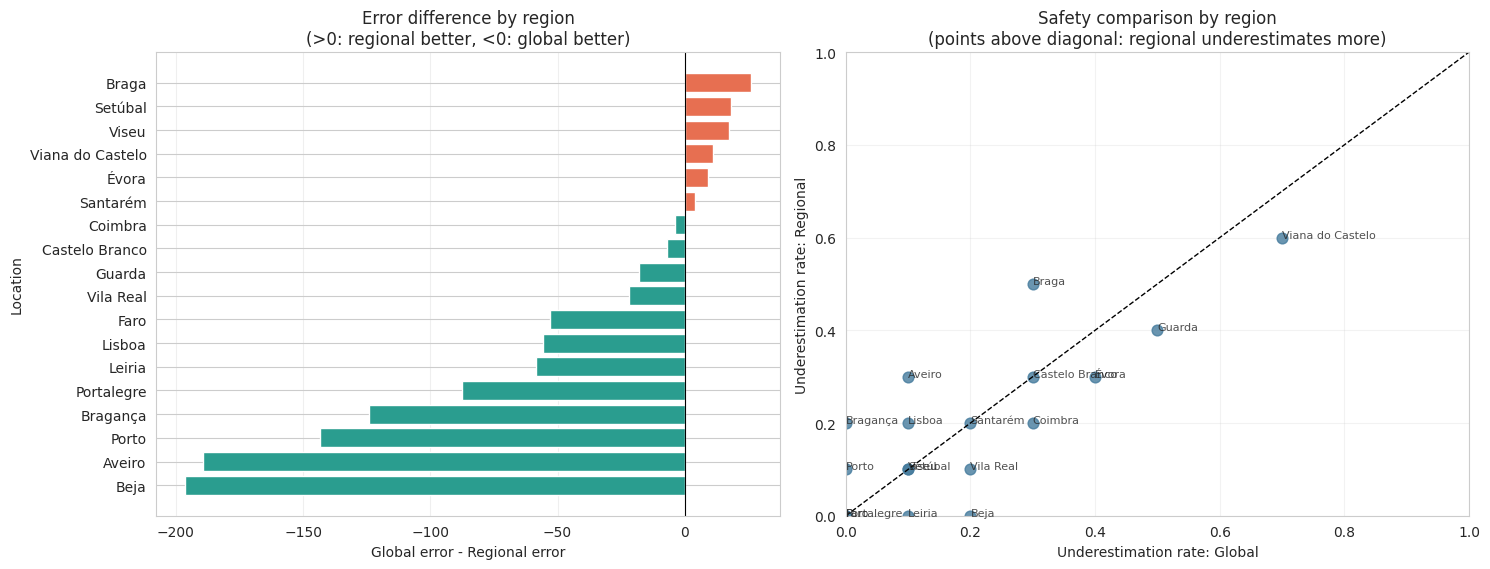

In [182]:
# Region-by-region comparison: where each strategy wins or loses
loc_eval = eval_df.groupby('location').agg(
    rows=('accident_count', 'count'),
    mean_actual_acc=('accident_count', 'mean'),
    mean_pred_global=('pred_global', 'mean'),
    mean_pred_regional=('pred_regional', 'mean'),
    total_vehicle_error_global=('vehicle_error_global', 'sum'),
    total_vehicle_error_regional=('vehicle_error_regional', 'sum'),
    under_rate_global=('under_global', 'mean'),
    under_rate_regional=('under_regional', 'mean')
).reset_index()

loc_eval['global_minus_regional_error'] = (
    loc_eval['total_vehicle_error_global'] - loc_eval['total_vehicle_error_regional']
)
loc_eval['winner'] = np.where(
    loc_eval['total_vehicle_error_global'] < loc_eval['total_vehicle_error_regional'],
    'Global',
    'Regional'
)
loc_eval = loc_eval.sort_values('global_minus_regional_error', ascending=False)

print('REGION-LEVEL PERFORMANCE COMPARISON')
print('=' * 90)
print(loc_eval.round(3).to_string(index=False))

print('\nTop regions where REGIONAL model is better (positive = global worse):')
print(loc_eval[['location', 'global_minus_regional_error']].head(6).round(3).to_string(index=False))

print('\nTop regions where GLOBAL model is better (negative = global better):')
print(loc_eval[['location', 'global_minus_regional_error']].tail(6).round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

plot_df = loc_eval.sort_values('global_minus_regional_error', ascending=True)
axes[0].barh(
    plot_df['location'],
    plot_df['global_minus_regional_error'],
    color=['#e76f51' if x > 0 else '#2a9d8f' for x in plot_df['global_minus_regional_error']]
)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Global error - Regional error')
axes[0].set_ylabel('Location')
axes[0].set_title('Error difference by region\n(>0: regional better, <0: global better)')
axes[0].grid(axis='x', alpha=0.3)

axes[1].scatter(loc_eval['under_rate_global'], loc_eval['under_rate_regional'], s=60, color='#457b9d', alpha=0.8)
for _, r in loc_eval.iterrows():
    axes[1].text(r['under_rate_global'], r['under_rate_regional'], r['location'], fontsize=8, alpha=0.8)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Underestimation rate: Global')
axes[1].set_ylabel('Underestimation rate: Regional')
axes[1].set_title('Safety comparison by region\n(points above diagonal: regional underestimates more)')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [183]:
# Final compact objective metrics (easy-to-read)
# Vehicle Error is the primary business objective.
# This table compares WITH uplift vs WITHOUT uplift.

actual_veh = 3 * eval_df['accident_count']

global_raw_veh = 3 * eval_df['pred_global_raw']
global_adj_veh = 3 * eval_df['pred_global']
regional_raw_veh = 3 * eval_df['pred_regional_raw']
regional_adj_veh = 3 * eval_df['pred_regional']

summary_simple = pd.DataFrame([
    {
        'Model': 'Global',
        'Mode': 'No uplift',
        'Total Vehicle Error': (actual_veh - global_raw_veh).abs().sum(),
        'Mean Vehicle Error': (actual_veh - global_raw_veh).abs().mean(),
        'Median Vehicle Error': (actual_veh - global_raw_veh).abs().median(),
        'P90 Vehicle Error': (actual_veh - global_raw_veh).abs().quantile(0.90),
        'Underestimation Rate': (eval_df['pred_global_raw'] < eval_df['accident_count']).mean(),
        'Total Actual Vehicles': actual_veh.sum(),
        'Total Pred Vehicles': global_raw_veh.sum()
    },
    {
        'Model': 'Global',
        'Mode': 'With uplift',
        'Total Vehicle Error': (actual_veh - global_adj_veh).abs().sum(),
        'Mean Vehicle Error': (actual_veh - global_adj_veh).abs().mean(),
        'Median Vehicle Error': (actual_veh - global_adj_veh).abs().median(),
        'P90 Vehicle Error': (actual_veh - global_adj_veh).abs().quantile(0.90),
        'Underestimation Rate': (eval_df['pred_global'] < eval_df['accident_count']).mean(),
        'Total Actual Vehicles': actual_veh.sum(),
        'Total Pred Vehicles': global_adj_veh.sum()
    },
    {
        'Model': 'Regional',
        'Mode': 'No uplift',
        'Total Vehicle Error': (actual_veh - regional_raw_veh).abs().sum(),
        'Mean Vehicle Error': (actual_veh - regional_raw_veh).abs().mean(),
        'Median Vehicle Error': (actual_veh - regional_raw_veh).abs().median(),
        'P90 Vehicle Error': (actual_veh - regional_raw_veh).abs().quantile(0.90),
        'Underestimation Rate': (eval_df['pred_regional_raw'] < eval_df['accident_count']).mean(),
        'Total Actual Vehicles': actual_veh.sum(),
        'Total Pred Vehicles': regional_raw_veh.sum()
    },
    {
        'Model': 'Regional',
        'Mode': 'With uplift',
        'Total Vehicle Error': (actual_veh - regional_adj_veh).abs().sum(),
        'Mean Vehicle Error': (actual_veh - regional_adj_veh).abs().mean(),
        'Median Vehicle Error': (actual_veh - regional_adj_veh).abs().median(),
        'P90 Vehicle Error': (actual_veh - regional_adj_veh).abs().quantile(0.90),
        'Underestimation Rate': (eval_df['pred_regional'] < eval_df['accident_count']).mean(),
        'Total Actual Vehicles': actual_veh.sum(),
        'Total Pred Vehicles': regional_adj_veh.sum()
    }
]).round(3)

summary_simple['Vehicle Bias (Pred-Actual)'] = (
    summary_simple['Total Pred Vehicles'] - summary_simple['Total Actual Vehicles']
).round(3)

# Improvement view: positive means uplift reduced vehicle error
comparison = []
for model_name in ['Global', 'Regional']:
    no_row = summary_simple[(summary_simple['Model'] == model_name) & (summary_simple['Mode'] == 'No uplift')].iloc[0]
    up_row = summary_simple[(summary_simple['Model'] == model_name) & (summary_simple['Mode'] == 'With uplift')].iloc[0]
    comparison.append({
        'Model': model_name,
        'Vehicle Error Improvement (NoUplift - Uplift)': no_row['Total Vehicle Error'] - up_row['Total Vehicle Error'],
        'Underestimation Rate Change (Uplift - NoUplift)': up_row['Underestimation Rate'] - no_row['Underestimation Rate']
    })
comparison_df = pd.DataFrame(comparison).round(3)

best_model = summary_simple.sort_values('Total Vehicle Error').iloc[0]

print('FINAL OBJECTIVE METRICS (WITH VS WITHOUT UPLIFT)')
print('=' * 90)
print(summary_simple.to_string(index=False))

print('\nUPLIFT IMPACT SUMMARY')
print('=' * 90)
print(comparison_df.to_string(index=False))

print('\nBest setup by Total Vehicle Error:')
print(f"{best_model['Model']} - {best_model['Mode']}")

FINAL OBJECTIVE METRICS (WITH VS WITHOUT UPLIFT)
   Model        Mode  Total Vehicle Error  Mean Vehicle Error  Median Vehicle Error  P90 Vehicle Error  Underestimation Rate  Total Actual Vehicles  Total Pred Vehicles  Vehicle Bias (Pred-Actual)
  Global   No uplift             2989.786              16.610                10.879             38.486                 0.439                  10698            12052.172                    1354.172
  Global With uplift             3470.414              19.280                12.042             45.231                 0.200                  10698            13402.172                    2704.172
Regional   No uplift             3805.903              21.144                14.939             47.503                 0.300                  10698            13122.121                    2424.121
Regional With uplift             4342.885              24.127                17.207             52.155                 0.200                  10698            1419

## Presentation Notes: What We Learned and Why the Final Design Is Defensible

### 1) Why top global correlations can be misleading
- Some weather variables looked highly correlated with accidents in the pooled dataset, but this mixes very different regions.
- Regions have different baseline traffic intensity, population density, and road usage. These baseline differences can dominate global correlations.
- Implication: a high global correlation does **not** automatically mean a strong within-region causal weather effect.

### 2) Simpson's Paradox in our context
- We observed cases where the global trend and the within-region trend were different (sometimes opposite).
- This is a Simpson's Paradox pattern: aggregation across heterogeneous groups can invert or distort relationships.
- We explicitly diagnosed this with:
  - Global vs median per-region correlation summaries.
  - Between-region vs within-region decomposition.
  - Extra pooled-vs-demeaned scatter diagnostics for the most confounded features.

### 3) How we tackled the confounding problem
- We did **not** drop weather features only because they were confounded globally.
- Instead, we controlled for group structure:
  - `location` one-hot encoding in the global model to absorb region-specific baseline accident levels.
  - Per-region model benchmark to test whether fully local models outperform a shared global model.
- This keeps weather signal while reducing attribution bias.

### 4) Why date-derived features matter (and why this is not cheating)
- Variables like `day_of_week`, `month`, and `is_weekend` are available at prediction time and represent normal traffic cycles.
- They serve as control variables so the model does not wrongly assign weekly traffic seasonality to weather.
- Without these controls, rain/snow effects can be overestimated or even directionally wrong.

### 5) Snow-specific challenge
- `snow_fall` is effectively binary in this dataset (0/1), so we represented it as `has_snow`.
- Snow effects are heterogeneous: some regions show higher accidents on snow days, others do not.
- Sample sizes for snow are limited in several regions, so uncertainty is higher; we therefore evaluate snow behavior with caution and region-level breakdowns.

### 6) Modeling and evaluation strategy used
- Chronological split to avoid future leakage.
- Two strategies compared on the same test period:
  - Global linear model with location controls.
  - Separate linear model per region.
- We used an objective-aware adjustment, not just a reporting metric:
  - A calibration-based **underestimation penalty uplift** was applied to predictions using recent residual quantiles.
  - This pushes predictions upward when the model has a systematic tendency to underestimate, aligning with safety requirements.
- Metrics reported include:
  - Vehicle Error (business metric).
  - Underestimation rate (safety-relevant).
  - Raw actual vs predicted values.
  - Region-by-region performance comparison.

### 7) Main difficulty and takeaway
- Main difficulty: separating true weather effects from strong regional baseline differences.
- Final takeaway: controlling for region and time is essential to interpret weather impacts responsibly and to build safer operational forecasts for vehicle allocation.

### 8) Uplift Impact
- The uplift adjustment reduced underestimation rates significantly, improving safety.
- This evidence shows that having simply a good Vehicle Error is not enough if we want to focus on safety.